# Emotion transition network explorer

This notebook asks a deliberately slippery question: **when the tone of comments moves gradually from one emotion to another, how does the embedding move?** Since GoEmotions comments are independent examples rather than chronological conversation turns, this notebook treats a "transition" as a **cross-sectional pseudo-transition**: comments are ordered along an affective path between two emotion endpoints.

The goal is to find emotion pairs where the embedding changes smoothly, bends, or refuses to cooperate because language enjoys being a swamp.


## Methodology

1. **Inputs.** Use GoEmotions comment metadata and comment embeddings. The notebook now supports both the original single-label metadata and a multi-label GoEmotions cache built from `train.tsv`. If multi-label mode is enabled but no compatible cache exists, the notebook falls back to the available metadata and prints instructions instead of pretending magic happened.
2. **Multi-label handling.** Each comment keeps a list of emotion labels (`label_names_list`). For display, `label_name` is the primary label, but label membership, endpoint bonuses, label counts, and emotion centroids use all labels attached to a comment.
3. **Affective coordinates.** Use the BRM/ANEW-style affect table, using only `V` and `D`, to give each emotion label and comment a valence/dominance coordinate. Comment VD is estimated from covered words; if no words are covered, the fallback is the mean VD of all labels assigned to that comment.
4. **Transition corridor.** For a source emotion and target emotion, project each comment VD point onto the source-target VD line. Keep comments near the segment and closest to the transition corridor.
5. **Embedding path.** Project selected comment embeddings onto the source-target embedding-centroid direction, bin comments by the affective coordinate `tone_t`, and compute an embedding centroid for each bin.
6. **Diagnostics.** Report monotonicity, straightness, coherence, and jitter. The notebook now also displays representative comments for every valid tone bin and draws an interactive 3D PCA plot of the binned embedding mean path.


## 0. Setup

Edit the paths in the next cell. The defaults try common locations in this project folder first.


In [1]:
from __future__ import annotations

import os
import re
import math
import json
import subprocess
from dataclasses import dataclass
from itertools import combinations
from pathlib import Path
from typing import Iterable, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

SEED = 42
rng = np.random.default_rng(SEED)

# All affective metrics in this notebook use valence and dominance only.
# The transition geometry is two-dimensional: valence plus dominance.
AFFECT_AXES = ["valence", "dominance"]
AFFECT_LABEL = "VD"

# Candidate roots. Add your local GoEmotions directory here if needed.
ROOT_CANDIDATES = [
    Path.cwd(),
    Path("/mnt/data"),
    Path("D:/pyprojects/m4r/data/goemotions"),
    Path("./data/goemotions"),
]

GOEMOTIONS_LABELS = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral",
]

LABEL_WORD_FALLBACKS = {
    "caring": "care",
}


def first_existing(*paths: Path) -> Path | None:
    for path in paths:
        if path is not None and Path(path).exists():
            return Path(path)
    return None


def candidates(*relative_parts: str) -> list[Path]:
    return [root.joinpath(*relative_parts) for root in ROOT_CANDIDATES]

# Precomputed comment embeddings created by goemotions_embed_pipeline.py.
METADATA_PATH = first_existing(
    *candidates("manifold_outputs", "metadata.csv"),
    *candidates("metadata.csv"),
)
EMBEDDINGS_PATH = first_existing(
    *candidates("manifold_outputs", "embeddings.npy"),
    *candidates("manifold_outputs", "embeddings.csv"),
    *candidates("embeddings.npy"),
    *candidates("x_embd.csv"),
)

# Word-level affect file supplied in this project; only valence and dominance are used.
VD_WORD_CSV = first_existing(
    *candidates("BRM-emot-submit.csv"),
    *candidates("emotion_label_vad_starter.csv"),
)

# GoEmotions raw data directory, only needed if you want to build embeddings from scratch.
DATA_DIR = first_existing(
    *[root for root in ROOT_CANDIDATES if (root / "train.tsv").exists()],
)

OUTPUT_DIR = Path("emotion_transition_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("METADATA_PATH:", METADATA_PATH)
print("EMBEDDINGS_PATH:", EMBEDDINGS_PATH)
print("VD_WORD_CSV:", VD_WORD_CSV)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


METADATA_PATH: D:\pyprojects\m4r\data\goemotions\manifold_outputs\metadata.csv
EMBEDDINGS_PATH: D:\pyprojects\m4r\data\goemotions\manifold_outputs\embeddings.npy
VD_WORD_CSV: D:\pyprojects\m4r\data\goemotions\BRM-emot-submit.csv
DATA_DIR: D:\pyprojects\m4r\data\goemotions
OUTPUT_DIR: D:\pyprojects\m4r\emotion_transition_outputs


## 1. Optional: build embeddings if they do not exist

This cell wraps the existing embedding builder. Keep `RUN_EMBEDDING_BUILDER = False` unless you have `OPENAI_API_KEY` set and a local GoEmotions `train.tsv`. The builder keeps metadata aligned with embeddings, uses single-label comments, and can stratify sampling.


In [2]:
RUN_EMBEDDING_BUILDER = False
MAX_TOTAL = 5000
MAX_PER_LABEL = 250
EMBEDDING_MODEL = "text-embedding-3-large"

if RUN_EMBEDDING_BUILDER:
    script = first_existing(*candidates("goemotions_embed_pipeline.py"))
    if script is None:
        raise FileNotFoundError("Could not find goemotions_embed_pipeline.py. Put it in this folder or update ROOT_CANDIDATES.")
    if DATA_DIR is None:
        raise FileNotFoundError("Could not find a GoEmotions data directory containing train.tsv.")
    if not os.getenv("OPENAI_API_KEY"):
        raise EnvironmentError("OPENAI_API_KEY is not set. Do not paste keys into notebooks. The robots are already disappointed.")

    cmd = [
        "python", str(script),
        "--data-dir", str(DATA_DIR),
        "--max-total", str(MAX_TOTAL),
        "--max-per-label", str(MAX_PER_LABEL),
        "--model", EMBEDDING_MODEL,
        "--embed-label-words",
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

    METADATA_PATH = DATA_DIR / "manifold_outputs" / "metadata.csv"
    EMBEDDINGS_PATH = DATA_DIR / "manifold_outputs" / "embeddings.npy"
    print("Built:", METADATA_PATH, EMBEDDINGS_PATH)


## 1b. Optional: include multi-label GoEmotions comments

The original embedding builder used only single-label comments. This section adds a separate cache for **all GoEmotions comments with one or more labels**. It preserves all labels in `label_names`, uses the first listed label as `label_name` only for compact display, and keeps `n_labels` so multi-label rows are visible.

Set `RUN_MULTILABEL_EMBEDDING_BUILDER = True` only when `OPENAI_API_KEY` is available and `train.tsv` exists locally. Otherwise, place compatible files at `emotion_transition_outputs/multilabel_cache/metadata_multilabel.csv` and `emotion_transition_outputs/multilabel_cache/embeddings_multilabel.npy`.


In [3]:
INCLUDE_MULTI_LABEL_COMMENTS = True
RUN_MULTILABEL_EMBEDDING_BUILDER = False
MULTILABEL_MAX_TOTAL = 6000
MULTILABEL_MAX_PER_PRIMARY_LABEL = 350
MULTILABEL_BATCH_SIZE = 256
MULTILABEL_EMBEDDING_MODEL = EMBEDDING_MODEL
MULTILABEL_TEXT_TEMPLATE = "{text}"

MULTILABEL_CACHE_DIR = OUTPUT_DIR / "multilabel_cache"
MULTILABEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
MULTILABEL_METADATA_PATH = MULTILABEL_CACHE_DIR / "metadata_multilabel.csv"
MULTILABEL_EMBEDDINGS_PATH = MULTILABEL_CACHE_DIR / "embeddings_multilabel.npy"


def parse_label_indices(value: object) -> list[int]:
    """Parse GoEmotions label strings such as '17', '17,25', '[17, 25]', or '17 25'."""
    nums = [int(x) for x in re.findall(r"\d+", str(value))]
    return [i for i in nums if 0 <= i < len(GOEMOTIONS_LABELS)]


def load_multilabel_goemotions(tsv_path: Path, max_total: int | None = None, max_per_primary_label: int | None = None, seed: int = SEED) -> pd.DataFrame:
    raw = pd.read_csv(tsv_path, sep="\t", header=None, usecols=[0, 1], names=["text", "label_raw"])
    raw["label_indices_list"] = raw["label_raw"].map(parse_label_indices)
    raw = raw[raw["label_indices_list"].map(len) > 0].copy()
    raw["label_names_list"] = raw["label_indices_list"].map(lambda ids: [GOEMOTIONS_LABELS[i] for i in ids])
    raw["label_idx"] = raw["label_indices_list"].map(lambda ids: ids[0])
    raw["label_name"] = raw["label_names_list"].map(lambda labs: labs[0])
    raw["label_indices"] = raw["label_indices_list"].map(lambda ids: "|".join(map(str, ids)))
    raw["label_names"] = raw["label_names_list"].map(lambda labs: "|".join(labs))
    raw["n_labels"] = raw["label_names_list"].map(len)
    raw["original_row"] = raw.index
    raw["embedding_text"] = raw["text"].map(lambda t: MULTILABEL_TEXT_TEMPLATE.format(text=str(t)))

    out = raw[["original_row", "text", "label_raw", "label_idx", "label_name", "label_indices", "label_names", "n_labels", "embedding_text"]].reset_index(drop=True)

    if max_per_primary_label is not None:
        out = (
            out.groupby("label_name", group_keys=False)
            .apply(lambda g: g.sample(n=min(len(g), max_per_primary_label), random_state=seed))
            .reset_index(drop=True)
        )
    if max_total is not None and len(out) > max_total:
        out = out.sample(n=max_total, random_state=seed).reset_index(drop=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


def embed_texts_openai(texts: Sequence[str], model: str, batch_size: int = 256, max_chars: int = 8190) -> np.ndarray:
    from openai import OpenAI

    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        raise EnvironmentError("OPENAI_API_KEY is not set. Set it before running the multi-label embedding builder.")
    client = OpenAI(api_key=api_key)
    rows = []
    cleaned = [str(t).replace("\n", " ").strip()[:max_chars] for t in texts]
    for start in range(0, len(cleaned), batch_size):
        chunk = cleaned[start:start + batch_size]
        print(f"Embedding multi-label batch {start // batch_size + 1}: {len(chunk)} texts")
        response = client.embeddings.create(input=chunk, model=model)
        rows.extend([item.embedding for item in response.data])
    arr = np.asarray(rows, dtype=np.float32)
    if arr.shape[0] != len(cleaned):
        raise RuntimeError(f"Expected {len(cleaned)} embeddings, got {arr.shape[0]}")
    return arr


def prepare_multilabel_cache() -> tuple[Path | None, Path | None]:
    if not INCLUDE_MULTI_LABEL_COMMENTS:
        return None, None

    if MULTILABEL_METADATA_PATH.exists() and MULTILABEL_EMBEDDINGS_PATH.exists():
        print("Using existing multi-label cache:", MULTILABEL_METADATA_PATH, MULTILABEL_EMBEDDINGS_PATH)
        return MULTILABEL_METADATA_PATH, MULTILABEL_EMBEDDINGS_PATH

    train_tsv = first_existing(
        *(candidates("train.tsv")),
        *(([DATA_DIR / "train.tsv"] if DATA_DIR is not None else [])),
    )
    if RUN_MULTILABEL_EMBEDDING_BUILDER:
        if train_tsv is None:
            raise FileNotFoundError("Could not find GoEmotions train.tsv for multi-label embedding builder.")
        multi_meta = load_multilabel_goemotions(
            train_tsv,
            max_total=MULTILABEL_MAX_TOTAL,
            max_per_primary_label=MULTILABEL_MAX_PER_PRIMARY_LABEL,
            seed=SEED,
        )
        multi_X = embed_texts_openai(
            multi_meta["embedding_text"].tolist(),
            model=MULTILABEL_EMBEDDING_MODEL,
            batch_size=MULTILABEL_BATCH_SIZE,
        )
        multi_meta.to_csv(MULTILABEL_METADATA_PATH, index=False)
        np.save(MULTILABEL_EMBEDDINGS_PATH, multi_X)
        print("Saved multi-label metadata:", MULTILABEL_METADATA_PATH)
        print("Saved multi-label embeddings:", MULTILABEL_EMBEDDINGS_PATH, multi_X.shape)
        return MULTILABEL_METADATA_PATH, MULTILABEL_EMBEDDINGS_PATH

    print(
        "Multi-label mode is enabled, but no cache was found. "
        "Run this cell with RUN_MULTILABEL_EMBEDDING_BUILDER=True, or provide the cache files. "
        "For now the notebook will use the existing single-label metadata/embeddings."
    )
    return None, None


multi_meta_path, multi_emb_path = prepare_multilabel_cache()
if multi_meta_path is not None and multi_emb_path is not None:
    METADATA_PATH = multi_meta_path
    EMBEDDINGS_PATH = multi_emb_path


Multi-label mode is enabled, but no cache was found. Run this cell with RUN_MULTILABEL_EMBEDDING_BUILDER=True, or provide the cache files. For now the notebook will use the existing single-label metadata/embeddings.


## 2. Load embeddings, metadata, and VD lexicon


In [4]:
def load_embeddings(path: Path) -> np.ndarray:
    path = Path(path)
    if path.suffix.lower() == ".npy":
        return np.load(path)
    return pd.read_csv(path, header=None).to_numpy(dtype=np.float32)


def l2_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)


def require_file(path: Path | None, name: str) -> Path:
    if path is None or not Path(path).exists():
        raise FileNotFoundError(
            f"Missing {name}. Set the path in the setup cell or run the embedding builder. Missing value: {path}"
        )
    return Path(path)


def split_label_names(value: object) -> list[str]:
    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    if "|" in text:
        parts = text.split("|")
    elif "," in text and not text.startswith("["):
        parts = text.split(",")
    else:
        # Handles single labels and rough stringified lists.
        cleaned = re.sub(r"[\[\]'\"]", "", text)
        parts = cleaned.split(",") if "," in cleaned else [cleaned]
    return [p.strip() for p in parts if p.strip()]


def normalize_metadata_labels(metadata: pd.DataFrame) -> pd.DataFrame:
    out = metadata.copy().reset_index(drop=True)

    if "label_names" in out.columns:
        out["label_names_list"] = out["label_names"].map(split_label_names)
    elif "label_name" in out.columns:
        out["label_names_list"] = out["label_name"].map(lambda x: [str(x)] if pd.notna(x) else [])
    elif "label_raw" in out.columns:
        out["label_names_list"] = out["label_raw"].map(lambda raw: [GOEMOTIONS_LABELS[i] for i in parse_label_indices(raw)])
    else:
        raise ValueError("metadata needs either label_names, label_name, or label_raw so labels can be recovered.")

    bad = out["label_names_list"].map(len).eq(0)
    if bad.any():
        raise ValueError(f"{bad.sum()} metadata rows have no parseable labels.")

    if "label_name" not in out.columns:
        out["label_name"] = out["label_names_list"].map(lambda labs: labs[0])
    else:
        out["label_name"] = out.apply(
            lambda r: str(r["label_name"]) if pd.notna(r["label_name"]) and str(r["label_name"]).strip() else r["label_names_list"][0],
            axis=1,
        )

    out["label_names"] = out["label_names_list"].map(lambda labs: "|".join(labs))
    out["n_labels"] = out["label_names_list"].map(len)
    out["has_multiple_labels"] = out["n_labels"] > 1
    return out

metadata_path = require_file(METADATA_PATH, "metadata.csv")
embeddings_path = require_file(EMBEDDINGS_PATH, "embeddings.npy or embeddings.csv")
vd_word_path = require_file(VD_WORD_CSV, "BRM/ANEW VD CSV")

metadata = pd.read_csv(metadata_path)
metadata = normalize_metadata_labels(metadata)
X_raw = load_embeddings(embeddings_path)
X = l2_normalize(X_raw)

if len(metadata) != len(X):
    raise ValueError(f"metadata rows ({len(metadata)}) != embedding rows ({len(X)}). Humanity has aligned fewer things than this, but still.")

print("metadata:", metadata.shape)
print("embeddings:", X.shape)
print("multi-label comments:", int(metadata["has_multiple_labels"].sum()), "/", len(metadata))
display(metadata[["text", "label_name", "label_names", "n_labels"]].head())


metadata: (4997, 9)
embeddings: (4997, 3072)
multi-label comments: 0 / 4997


,text,label_name,label_names,n_labels
0,Your idea of what a nice entre or nice wine co...,admiration,admiration,1
1,I am so relieved,relief,relief,1
2,A reason to play the game every 3 month?,curiosity,curiosity,1
3,Lakers truly have the worst fans,annoyance,annoyance,1
4,Great way to clarify! That's the whole point o...,approval,approval,1


In [5]:
def load_word_vd(path: Path) -> pd.DataFrame:
    affect = pd.read_csv(path)
    # Support either BRM columns Word/V/D or already-normalized label_name/valence/dominance.
    # Extra affect columns may exist in the file, but only valence and dominance are loaded.
    rename = {}
    if "Word" in affect.columns:
        rename["Word"] = "word"
    if "V" in affect.columns:
        rename["V"] = "valence"
    elif "V.Mean.Sum" in affect.columns:
        rename["V.Mean.Sum"] = "valence"
    if "D" in affect.columns:
        rename["D"] = "dominance"
    elif "D.Mean.Sum" in affect.columns:
        rename["D.Mean.Sum"] = "dominance"
    if "label_name" in affect.columns and "word" not in affect.columns:
        rename["label_name"] = "word"
    affect = affect.rename(columns=rename).copy()
    required = {"word", "valence", "dominance"}
    missing = required - set(affect.columns)
    if missing:
        raise ValueError(f"VD file missing columns: {sorted(missing)}")
    affect = affect[["word", "valence", "dominance"]].dropna().copy()
    affect["word"] = affect["word"].astype(str).str.lower().str.strip()
    for col in AFFECT_AXES:
        affect[col] = pd.to_numeric(affect[col], errors="coerce")
    affect = affect.dropna(subset=AFFECT_AXES)
    return affect.drop_duplicates("word")

word_vd = load_word_vd(vd_word_path)
word_vd_map = word_vd.set_index("word")[AFFECT_AXES]
print("word VD rows:", len(word_vd))
display(word_vd.head())

word VD rows: 13904


,word,valence,dominance
0,aardvark,6.26,4.27
1,abalone,5.30,4.95
2,abandon,2.84,3.32
3,abandonment,2.63,2.64
4,abbey,5.85,5.00


## 3. Build emotion-label VD coordinates

These coordinates define the endpoints for emotion transitions. Most GoEmotions labels are direct words in the lexicon; `caring` is mapped to `care`.


In [6]:
def make_label_vd(labels: Sequence[str], word_vd_map: pd.DataFrame, fallbacks: dict[str, str]) -> pd.DataFrame:
    rows = []
    missing = []
    for label in labels:
        lookup = fallbacks.get(label, label).lower()
        if lookup not in word_vd_map.index:
            missing.append((label, lookup))
            continue
        vals = word_vd_map.loc[lookup]
        rows.append({
            "label_name": label,
            "vd_lookup_word": lookup,
            "valence": float(vals["valence"]),
            "dominance": float(vals["dominance"]),
        })
    if missing:
        raise ValueError(f"Missing VD label words: {missing}")
    return pd.DataFrame(rows)

all_comment_labels = set(lab for labs in metadata["label_names_list"] for lab in labs)
labels_present = [lab for lab in GOEMOTIONS_LABELS if lab in all_comment_labels]
label_vd = make_label_vd(labels_present, word_vd_map, LABEL_WORD_FALLBACKS)
label_vad = label_vd  # Backward-compatible alias for later cells and older saved outputs.
label_vd_path = OUTPUT_DIR / "emotion_label_vd_from_BRM.csv"
label_vd.to_csv(label_vd_path, index=False)
print("Saved label VD:", label_vd_path)
display(label_vd.sort_values("valence"))

Saved label VD: emotion_transition_outputs\emotion_label_vd_from_BRM.csv


,label_name,vd_lookup_word,valence,dominance
16,grief,grief,2.33,3.26
25,sadness,sadness,2.40,3.84
2,anger,anger,2.50,5.14
12,embarrassment,embarrassment,2.72,2.92
9,disappointment,disappointment,2.79,4.08
14,fear,fear,2.93,3.32
3,annoyance,annoyance,2.95,3.45
19,nervousness,nervousness,3.10,3.93
6,confusion,confusion,3.32,3.08
11,disgust,disgust,3.32,4.84


## 4. Estimate comment-level lexical VD

This is the mechanism that lets us talk about gradual shifts. A comment with words such as "happy", "relieved", and "safe" lands in a different part of VD space than one with "angry", "disgusted", and "afraid", even if both are only represented by a single GoEmotions label. It is a blunt lexical instrument, not a mind reader. Luckily, we only asked it to be a coordinate system.


In [7]:
WORD_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")


def tokenize(text: object) -> list[str]:
    return WORD_RE.findall(str(text).lower())


def text_vd(text: object, word_vd_map: pd.DataFrame) -> tuple[float, float, int]:
    toks = tokenize(text)
    hits = [tok for tok in toks if tok in word_vd_map.index]
    if not hits:
        return (np.nan, np.nan, 0)
    arr = word_vd_map.loc[hits][AFFECT_AXES].to_numpy(dtype=float)
    vals = arr.mean(axis=0)
    return (float(vals[0]), float(vals[1]), len(hits))


def mean_label_vd(label_names: Sequence[str], label_lookup: pd.DataFrame) -> tuple[float, float, str]:
    labs = [lab for lab in label_names if lab in label_lookup.index]
    if not labs:
        return (np.nan, np.nan, "")
    arr = label_lookup.loc[labs][AFFECT_AXES].to_numpy(dtype=float)
    vals = arr.mean(axis=0)
    lookup_words = label_lookup.loc[labs]["vd_lookup_word"].astype(str).tolist()
    return (float(vals[0]), float(vals[1]), "|".join(lookup_words))


def attach_vd_to_comments(metadata: pd.DataFrame, label_vd: pd.DataFrame, word_vd_map: pd.DataFrame) -> pd.DataFrame:
    out = metadata.copy().reset_index(drop=True)
    if "text" not in out.columns:
        raise ValueError("metadata must contain a 'text' column. The embedding builder writes this automatically.")

    label_lookup = label_vd.set_index("label_name")[AFFECT_AXES + ["vd_lookup_word"]]
    label_vals = out["label_names_list"].map(lambda labs: mean_label_vd(labs, label_lookup))
    label_arr = np.array([x[:2] for x in label_vals], dtype=float)
    out["label_valence"] = label_arr[:, 0]
    out["label_dominance"] = label_arr[:, 1]
    out["vd_lookup_word"] = [x[2] for x in label_vals]

    if out[["label_valence", "label_dominance"]].isna().any().any():
        bad = out[out["label_valence"].isna()][["label_names"]].drop_duplicates().head(20)
        raise ValueError("Some rows have labels missing from label_vd. Examples:\n" + bad.to_string(index=False))

    vals = out["text"].map(lambda s: text_vd(s, word_vd_map))
    vd_arr = np.array(vals.tolist(), dtype=float)
    out["lex_valence"] = vd_arr[:, 0]
    out["lex_dominance"] = vd_arr[:, 1]
    out["lex_vd_n_words"] = vd_arr[:, 2].astype(int)

    # Fallback to the mean label VD when the comment has no lexicon-covered words.
    for axis in AFFECT_AXES:
        out[f"comment_{axis}"] = out[f"lex_{axis}"].fillna(out[f"label_{axis}"])
    out["comment_vd_source"] = np.where(out["lex_vd_n_words"] > 0, "lexical_average", "mean_label_fallback")

    # Backward-compatible aliases for older cells/output names. They still use VD only.
    out["lex_vad_n_words"] = out["lex_vd_n_words"]
    out["comment_vad_source"] = out["comment_vd_source"]
    return out

meta_vd = attach_vd_to_comments(metadata, label_vd, word_vd_map)
meta_vad = meta_vd  # Backward-compatible alias; only VD columns are present or used.
print(meta_vd["comment_vd_source"].value_counts(dropna=False))
print("Mean lexicon-covered VD words per comment:", meta_vd["lex_vd_n_words"].mean().round(2))
print("Multi-label comments after VD attachment:", int(meta_vd["has_multiple_labels"].sum()), "/", len(meta_vd))
display(meta_vd[["text", "label_name", "label_names", "n_labels", "comment_valence", "comment_dominance", "lex_vd_n_words", "comment_vd_source"]].head(10))

comment_vd_source
lexical_average        4848
mean_label_fallback     149
Name: count, dtype: int64
Mean lexicon-covered VD words per comment: 4.08
Multi-label comments after VD attachment: 0 / 4997


,text,label_name,label_names,n_labels,comment_valence,comment_dominance,lex_vd_n_words,comment_vd_source
0,Your idea of what a nice entre or nice wine co...,admiration,admiration,1,6.377143,5.862857,7,lexical_average
1,I am so relieved,relief,relief,1,6.630000,5.640000,0,mean_label_fallback
2,A reason to play the game every 3 month?,curiosity,curiosity,1,6.597500,5.822500,4,lexical_average
3,Lakers truly have the worst fans,annoyance,annoyance,1,5.860000,5.720000,1,lexical_average
4,Great way to clarify! That's the whole point o...,approval,approval,1,6.288571,5.877143,7,lexical_average
5,I'm surprised everyone seems to think there wi...,surprise,surprise,1,6.292000,5.898000,5,lexical_average
6,I mean New Orleans is really fun even with lit...,admiration,admiration,1,6.390000,5.583333,6,lexical_average
7,Depends on the drug. Weed makes me antisocial ...,nervousness,nervousness,1,5.105556,5.136667,9,lexical_average
8,You probably can. They're shit at hurling.,annoyance,annoyance,1,5.160000,5.515000,2,lexical_average
9,"I'm terrible sorry, /u/bookluvr83, but I'm afr...",fear,fear,1,3.975714,4.445714,7,lexical_average


## 5. Emotion centroids and transition geometry


In [8]:
def normalized_centroid(points: np.ndarray) -> np.ndarray:
    c = points.mean(axis=0)
    return c / max(np.linalg.norm(c), 1e-12)


def contains_label(label_names: object, label: str) -> bool:
    labs = label_names if isinstance(label_names, list) else split_label_names(label_names)
    return label in labs


def exploded_label_counts(df: pd.DataFrame) -> pd.Series:
    return df["label_names_list"].explode().value_counts()


def build_embedding_centroids(X: np.ndarray, meta: pd.DataFrame) -> dict[str, np.ndarray]:
    """Build one centroid per label using every row that contains that label.

    Single-label metadata is a special case. Multi-label comments contribute to
    every label they contain, which is the whole point of this new experiment,
    because apparently one Reddit sentence can feel six things at once.
    """
    centroids = {}
    for label in labels_present:
        mask = meta["label_names_list"].map(lambda labs: label in labs).to_numpy()
        if mask.any():
            centroids[str(label)] = normalized_centroid(X[mask])
    return centroids

embedding_centroids = build_embedding_centroids(X, meta_vd)
label_vd_map = label_vd.set_index("label_name")[AFFECT_AXES]
label_vad_map = label_vd_map  # Backward-compatible alias; it contains valence and dominance only.

exploded = meta_vd.reset_index(names="row_id").explode("label_names_list").rename(columns={"label_names_list": "exploded_label"})
centroid_summary = (
    exploded.groupby("exploded_label")
    .agg(
        n_label_memberships=("exploded_label", "size"),
        n_unique_comments=("row_id", "nunique"),
        mean_comment_valence=("comment_valence", "mean"),
        mean_comment_dominance=("comment_dominance", "mean"),
        lexical_coverage=("lex_vd_n_words", lambda s: float((s > 0).mean())),
        multi_label_fraction=("has_multiple_labels", "mean"),
    )
    .reset_index()
    .rename(columns={"exploded_label": "label_name"})
    .merge(label_vd, on="label_name", how="left")
)
display(centroid_summary.sort_values("n_label_memberships", ascending=False))

,label_name,n_label_memberships,n_unique_comments,mean_comment_valence,mean_comment_dominance,lexical_coverage,multi_label_fraction,vd_lookup_word,valence,dominance
0,admiration,201,201,6.443734,5.933756,0.985075,0.0,admiration,7.58,6.11
1,amusement,201,201,5.932631,5.680784,0.940299,0.0,amusement,7.00,6.59
2,anger,201,201,5.021877,5.231483,0.985075,0.0,anger,2.50,5.14
3,annoyance,201,201,5.373612,5.394006,0.990050,0.0,annoyance,2.95,3.45
4,approval,201,201,5.979721,5.850101,0.955224,0.0,approval,6.75,6.63
5,caring,201,201,6.010351,5.723611,0.985075,0.0,care,7.64,6.56
6,confusion,201,201,5.551463,5.498511,0.975124,0.0,confusion,3.32,3.08
7,curiosity,201,201,5.715728,5.640843,0.925373,0.0,curiosity,6.37,6.21
8,desire,201,201,6.142922,5.772332,0.995025,0.0,desire,7.05,6.07
9,disappointment,201,201,5.245900,5.317779,0.965174,0.0,disappointment,2.79,4.08


In [9]:
def transition_coordinates(vads: np.ndarray, source_vad: np.ndarray, target_vad: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    '''Project VD points onto source->target VAD segment.

    Returns
    -------
    tone_t : array
        Scalar projection. 0 means source endpoint, 1 means target endpoint.
    tone_perp : array
        Euclidean distance from each VD point to the infinite source-target line.
    '''
    direction = target_vad - source_vad
    denom = float(np.dot(direction, direction))
    if denom < 1e-12:
        raise ValueError("Source and target VD endpoints are identical or too close.")
    centered = vads - source_vad[None, :]
    tone_t = centered @ direction / denom
    closest = source_vad[None, :] + tone_t[:, None] * direction[None, :]
    tone_perp = np.linalg.norm(vads - closest, axis=1)
    return tone_t, tone_perp


def embedding_transition_coordinates(X_points: np.ndarray, source_centroid: np.ndarray, target_centroid: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    '''Project embeddings onto the source->target embedding centroid vector.'''
    direction = target_centroid - source_centroid
    denom = float(np.dot(direction, direction))
    if denom < 1e-12:
        raise ValueError("Source and target embedding centroids are identical or too close.")
    centered = X_points - source_centroid[None, :]
    emb_t = centered @ direction / denom
    closest = source_centroid[None, :] + emb_t[:, None] * direction[None, :]
    emb_perp = np.linalg.norm(X_points - closest, axis=1)
    return emb_t, emb_perp


def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    a = a / max(np.linalg.norm(a), 1e-12)
    b = b / max(np.linalg.norm(b), 1e-12)
    return float(1.0 - np.clip(np.dot(a, b), -1.0, 1.0))


def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3 or np.nanstd(x[mask]) == 0 or np.nanstd(y[mask]) == 0:
        return np.nan
    return float(spearmanr(x[mask], y[mask]).statistic)


def safe_pearson(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3 or np.nanstd(x[mask]) == 0 or np.nanstd(y[mask]) == 0:
        return np.nan
    return float(pearsonr(x[mask], y[mask]).statistic)


## 6. Analyze one emotion transition

The function below selects comments near the VD line from `source` to `target`, bins them by tone position, and measures how their embeddings move.


In [10]:
def select_transition_corridor(
    meta: pd.DataFrame,
    X: np.ndarray,
    source: str,
    target: str,
    label_vad_map: pd.DataFrame,
    embedding_centroids: dict[str, np.ndarray],
    max_points: int = 1200,
    t_margin: float = 0.08,
    prefer_lexical_vad: bool = True,
    seed: int = SEED,
) -> dict:
    if source not in label_vad_map.index or target not in label_vad_map.index:
        raise ValueError(f"Unknown source/target labels: {source}, {target}")
    if source not in embedding_centroids or target not in embedding_centroids:
        raise ValueError(f"Missing source/target embedding centroids: {source}, {target}")

    vad_cols = ["comment_valence", "comment_dominance"] if prefer_lexical_vad else ["label_valence", "label_dominance"]
    vads = meta[vad_cols].to_numpy(dtype=float)
    source_vad = label_vad_map.loc[source].to_numpy(dtype=float)
    target_vad = label_vad_map.loc[target].to_numpy(dtype=float)
    tone_t, tone_perp = transition_coordinates(vads, source_vad, target_vad)

    source_centroid = embedding_centroids[source]
    target_centroid = embedding_centroids[target]
    emb_t, emb_perp = embedding_transition_coordinates(X, source_centroid, target_centroid)

    scored = meta.copy().reset_index(drop=False).rename(columns={"index": "row_id"})
    scored["tone_t"] = tone_t
    scored["tone_perp"] = tone_perp
    scored["embedding_t"] = emb_t
    scored["embedding_perp"] = emb_perp

    # Keep points projected near the segment. Then take the nearest points to the VD transition line.
    in_band = scored["tone_t"].between(-t_margin, 1 + t_margin)
    pool = scored.loc[in_band].copy()
    if pool.empty:
        pool = scored.copy()

    # Encourage comments that contain either endpoint label. Multi-label comments count here too.
    endpoint_mask = pool["label_names_list"].map(lambda labs: (source in labs) or (target in labs))
    pool["endpoint_bonus"] = np.where(endpoint_mask, -0.02, 0.0)
    pool["corridor_score"] = pool["tone_perp"] + pool["endpoint_bonus"]
    if len(pool) > max_points:
        pool = pool.sort_values("corridor_score", ascending=True).head(max_points)

    # Shuffle after selection to avoid plotting artifacts from sorted order.
    pool = pool.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    idx = pool["row_id"].to_numpy(dtype=int)

    return {
        "source": source,
        "target": target,
        "points": pool,
        "X_points": X[idx],
        "source_vad": source_vad,
        "target_vad": target_vad,
        "source_centroid": source_centroid,
        "target_centroid": target_centroid,
    }


def dominant_label_from_rows(rows: pd.DataFrame) -> str:
    counts = exploded_label_counts(rows)
    return str(counts.idxmax()) if len(counts) else ""


def binned_embedding_path(transition: dict, n_bins: int = 12, min_bin_count: int = 5) -> pd.DataFrame:
    points = transition["points"].copy()
    X_points = transition["X_points"]
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    centroids = []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = points["tone_t"].between(lo, hi, inclusive="both").to_numpy()
        else:
            mask = ((points["tone_t"] >= lo) & (points["tone_t"] < hi)).to_numpy()
        n = int(mask.sum())
        if n < min_bin_count:
            continue
        c = normalized_centroid(X_points[mask])
        centroids.append(c)
        bin_rows = points.loc[mask]
        rows.append({
            "bin": i,
            "tone_bin_low": float(lo),
            "tone_bin_high": float(hi),
            "tone_t_center": (lo + hi) / 2,
            "n": n,
            "n_multi_label": int(bin_rows["has_multiple_labels"].sum()) if "has_multiple_labels" in bin_rows else 0,
            "multi_label_fraction": float(bin_rows["has_multiple_labels"].mean()) if "has_multiple_labels" in bin_rows else np.nan,
            "mean_tone_t": float(bin_rows["tone_t"].mean()),
            "mean_tone_perp": float(bin_rows["tone_perp"].mean()),
            "mean_embedding_t": float(bin_rows["embedding_t"].mean()),
            "mean_embedding_perp": float(bin_rows["embedding_perp"].mean()),
            "dominant_label": dominant_label_from_rows(bin_rows),
        })

    path = pd.DataFrame(rows)
    if len(path):
        path.attrs["centroids"] = np.vstack(centroids)
    else:
        path.attrs["centroids"] = np.empty((0, X_points.shape[1]))
    return path


def summarize_transition(transition: dict, n_bins: int = 12, min_bin_count: int = 5) -> tuple[dict, pd.DataFrame]:
    points = transition["points"]
    path = binned_embedding_path(transition, n_bins=n_bins, min_bin_count=min_bin_count)
    C = path.attrs["centroids"]

    source = transition["source"]
    target = transition["target"]
    src_c = transition["source_centroid"]
    tgt_c = transition["target_centroid"]
    endpoint_vec = tgt_c - src_c
    endpoint_norm = max(np.linalg.norm(endpoint_vec), 1e-12)

    if len(C) >= 2:
        steps = np.diff(C, axis=0)
        step_lengths = np.linalg.norm(steps, axis=1)
        path_length = float(step_lengths.sum())
        direct_distance = float(np.linalg.norm(C[-1] - C[0]))
        straightness = float(direct_distance / path_length) if path_length > 1e-12 else np.nan
        step_coherences = (steps @ endpoint_vec) / np.maximum(np.linalg.norm(steps, axis=1) * endpoint_norm, 1e-12)
        mean_step_coherence = float(np.nanmean(step_coherences))
        path_jitter = float(np.nanstd(step_lengths) / max(np.nanmean(step_lengths), 1e-12)) if len(step_lengths) else np.nan
    else:
        path_length = direct_distance = straightness = mean_step_coherence = path_jitter = np.nan

    rho_t_embedding = safe_spearman(points["tone_t"].to_numpy(), points["embedding_t"].to_numpy())
    pearson_t_embedding = safe_pearson(points["tone_t"].to_numpy(), points["embedding_t"].to_numpy())
    rho_t_embedding_perp = safe_spearman(points["tone_t"].to_numpy(), points["embedding_perp"].to_numpy())

    vd_distance = float(np.linalg.norm(transition["target_vad"] - transition["source_vad"]))
    centroid_cosine_distance = cosine_distance(src_c, tgt_c)
    lexical_fraction = float((points["comment_vad_source"] == "lexical_average").mean()) if "comment_vad_source" in points else np.nan
    multi_label_fraction = float(points["has_multiple_labels"].mean()) if "has_multiple_labels" in points else np.nan

    # Compact ranking score. Negative monotonicity is treated as failure for source->target orientation.
    mono = max(0.0, rho_t_embedding) if np.isfinite(rho_t_embedding) else 0.0
    straight = max(0.0, straightness) if np.isfinite(straightness) else 0.0
    coherent = max(0.0, (mean_step_coherence + 1) / 2) if np.isfinite(mean_step_coherence) else 0.0
    sample_factor = min(1.0, math.log1p(len(points)) / math.log1p(1000))
    smooth_score = float(mono * straight * coherent * sample_factor)

    summary = {
        "source": source,
        "target": target,
        "n_points": int(len(points)),
        "n_labels": int(points["label_names_list"].explode().nunique()),
        "n_multi_label_points": int(points["has_multiple_labels"].sum()) if "has_multiple_labels" in points else 0,
        "multi_label_fraction": multi_label_fraction,
        "n_bins": int(len(path)),
        "vd_distance": vd_distance,
        "centroid_cosine_distance": centroid_cosine_distance,
        "rho_t_embedding_projection": rho_t_embedding,
        "pearson_t_embedding_projection": pearson_t_embedding,
        "rho_t_embedding_perp": rho_t_embedding_perp,
        "path_length": path_length,
        "direct_path_distance": direct_distance,
        "straightness": straightness,
        "mean_step_coherence": mean_step_coherence,
        "path_jitter": path_jitter,
        "lexical_vad_fraction": lexical_fraction,
        "smooth_score": smooth_score,
    }
    return summary, path


def analyze_transition(source: str, target: str, **kwargs) -> tuple[dict, pd.DataFrame, dict]:
    transition = select_transition_corridor(
        meta=meta_vd,
        X=X,
        source=source,
        target=target,
        label_vad_map=label_vad_map,
        embedding_centroids=embedding_centroids,
        **kwargs,
    )
    summary, path = summarize_transition(transition)
    return transition, path, summary


## 7. Scan all emotion pairs

This ranks transitions by how smoothly the embedding follows the affective source-target path.


In [11]:
def scan_all_transitions(
    labels: Sequence[str],
    max_points: int = 1000,
    t_margin: float = 0.08,
    min_points: int = 80,
    n_bins: int = 12,
    min_bin_count: int = 5,
) -> pd.DataFrame:
    rows = []
    for source, target in combinations(labels, 2):
        for s, t in [(source, target), (target, source)]:
            try:
                tr = select_transition_corridor(
                    meta=meta_vad,
                    X=X,
                    source=s,
                    target=t,
                    label_vad_map=label_vad_map,
                    embedding_centroids=embedding_centroids,
                    max_points=max_points,
                    t_margin=t_margin,
                )
                if len(tr["points"]) < min_points:
                    continue
                summary, _ = summarize_transition(tr, n_bins=n_bins, min_bin_count=min_bin_count)
                rows.append(summary)
            except Exception as exc:
                rows.append({"source": s, "target": t, "error": repr(exc)})
    results = pd.DataFrame(rows)
    if "smooth_score" in results.columns:
        results = results.sort_values("smooth_score", ascending=False).reset_index(drop=True)
    return results

transition_results = scan_all_transitions(labels_present)
results_path = OUTPUT_DIR / "emotion_transition_metrics.csv"
transition_results.to_csv(results_path, index=False)
print("Saved transition metrics:", results_path)
display(transition_results.head(20))


Saved transition metrics: emotion_transition_outputs\emotion_transition_metrics.csv


,source,target,n_points,n_labels,n_multi_label_points,multi_label_fraction,n_bins,vd_distance,centroid_cosine_distance,rho_t_embedding_projection,pearson_t_embedding_projection,rho_t_embedding_perp,path_length,direct_path_distance,straightness,mean_step_coherence,path_jitter,lexical_vad_fraction,smooth_score
0,pride,embarrassment,1000,28,0,0.0,7,4.770377,0.317987,0.373200,0.369826,-0.086425,2.656400,0.820841,0.309005,0.096387,0.356572,0.996,0.063218
1,embarrassment,pride,1000,28,0,0.0,7,4.770377,0.317987,0.373200,0.369826,0.086426,2.656400,0.820841,0.309005,0.096387,0.356572,0.996,0.063218
2,disgust,joy,1000,28,0,0.0,12,5.345811,0.380310,0.587736,0.594380,-0.170248,5.530749,0.990611,0.179110,0.123548,0.363347,0.952,0.059138
3,joy,disgust,1000,28,0,0.0,12,5.345811,0.380310,0.587736,0.594380,0.170248,5.530750,0.990612,0.179110,0.123548,0.363347,0.952,0.059138
4,grief,joy,1000,28,0,0.0,10,6.968644,0.419475,0.498812,0.473891,-0.230579,4.486609,0.966136,0.215338,0.095886,0.356487,0.991,0.058856
5,joy,grief,1000,28,0,0.0,10,6.968644,0.419475,0.498812,0.473891,0.230579,4.486609,0.966136,0.215338,0.095886,0.356487,0.991,0.058856
6,fear,joy,1000,28,0,0.0,11,6.435899,0.378018,0.549232,0.554275,-0.038219,4.934981,0.920643,0.186554,0.134625,0.339865,0.984,0.058128
7,joy,fear,1000,28,0,0.0,11,6.435899,0.378018,0.549232,0.554275,0.038219,4.934981,0.920643,0.186554,0.134625,0.339865,0.984,0.058128
8,disgust,admiration,1000,28,0,0.0,12,4.445278,0.319366,0.522944,0.513057,-0.032077,5.378456,1.028731,0.191269,0.132633,0.391453,0.988,0.056645
9,admiration,disgust,1000,28,0,0.0,12,4.445278,0.319366,0.522944,0.513057,0.032077,5.378457,1.028731,0.191269,0.132633,0.391453,0.988,0.056645


In [12]:
# The most curved transitions among ones that still move monotonically.
if not transition_results.empty:
    curved = transition_results.copy()
    curved = curved[np.isfinite(curved["straightness"]) & (curved["rho_t_embedding_projection"] > 0.25)]
    curved["curvature_score"] = (1 - curved["straightness"].clip(0, 1)) * curved["rho_t_embedding_projection"].clip(lower=0)
    curved = curved.sort_values("curvature_score", ascending=False)
    display(curved.head(20))


,source,target,n_points,n_labels,n_multi_label_points,multi_label_fraction,n_bins,vd_distance,centroid_cosine_distance,rho_t_embedding_projection,pearson_t_embedding_projection,rho_t_embedding_perp,path_length,direct_path_distance,straightness,mean_step_coherence,path_jitter,lexical_vad_fraction,smooth_score,curvature_score
3,joy,disgust,1000,28,0,0.0,12,5.345811,0.380310,0.587736,0.594380,0.170248,5.530750,0.990612,0.179110,0.123548,0.363347,0.952,0.059138,0.482467
2,disgust,joy,1000,28,0,0.0,12,5.345811,0.380310,0.587736,0.594380,-0.170248,5.530749,0.990611,0.179110,0.123548,0.363347,0.952,0.059138,0.482467
19,joy,anger,1000,28,0,0.0,12,6.005306,0.327938,0.566663,0.555009,0.243656,6.203740,0.995174,0.160415,0.123312,0.396521,0.933,0.051055,0.475762
18,anger,joy,1000,28,0,0.0,12,6.005306,0.327938,0.566663,0.555009,-0.243656,6.203739,0.995174,0.160415,0.123312,0.396521,0.933,0.051055,0.475762
50,joy,sadness,1000,28,0,0.0,12,6.613751,0.280577,0.555209,0.546634,0.101181,5.997330,0.888984,0.148230,0.129351,0.381864,0.978,0.046472,0.472910
51,sadness,joy,1000,28,0,0.0,12,6.613751,0.280577,0.555209,0.546634,-0.101181,5.997331,0.888984,0.148230,0.129351,0.381864,0.978,0.046472,0.472910
26,disappointment,joy,1000,28,0,0.0,12,6.156525,0.284568,0.559881,0.552975,-0.095482,5.808173,0.937735,0.161451,0.117947,0.380408,0.978,0.050527,0.469488
27,joy,disappointment,1000,28,0,0.0,12,6.156525,0.284568,0.559881,0.552975,0.095482,5.808173,0.937735,0.161451,0.117947,0.380408,0.978,0.050527,0.469488
56,admiration,fear,1000,28,0,0.0,12,5.422785,0.337272,0.546697,0.533277,0.060584,5.471282,0.820046,0.149882,0.110314,0.359477,0.971,0.045490,0.464757
57,fear,admiration,1000,28,0,0.0,12,5.422785,0.337272,0.546696,0.533277,-0.060588,5.471282,0.820046,0.149882,0.110314,0.359477,0.971,0.045489,0.464756


## 8. Plot the transition network

Nodes are emotion labels placed by valence/dominance. Edges are the highest-scoring smooth transitions. This is a network picture, not a claim that your feelings use graph theory. They probably use worse infrastructure.


Saved: emotion_transition_outputs\transition_network_valence_dominance.png


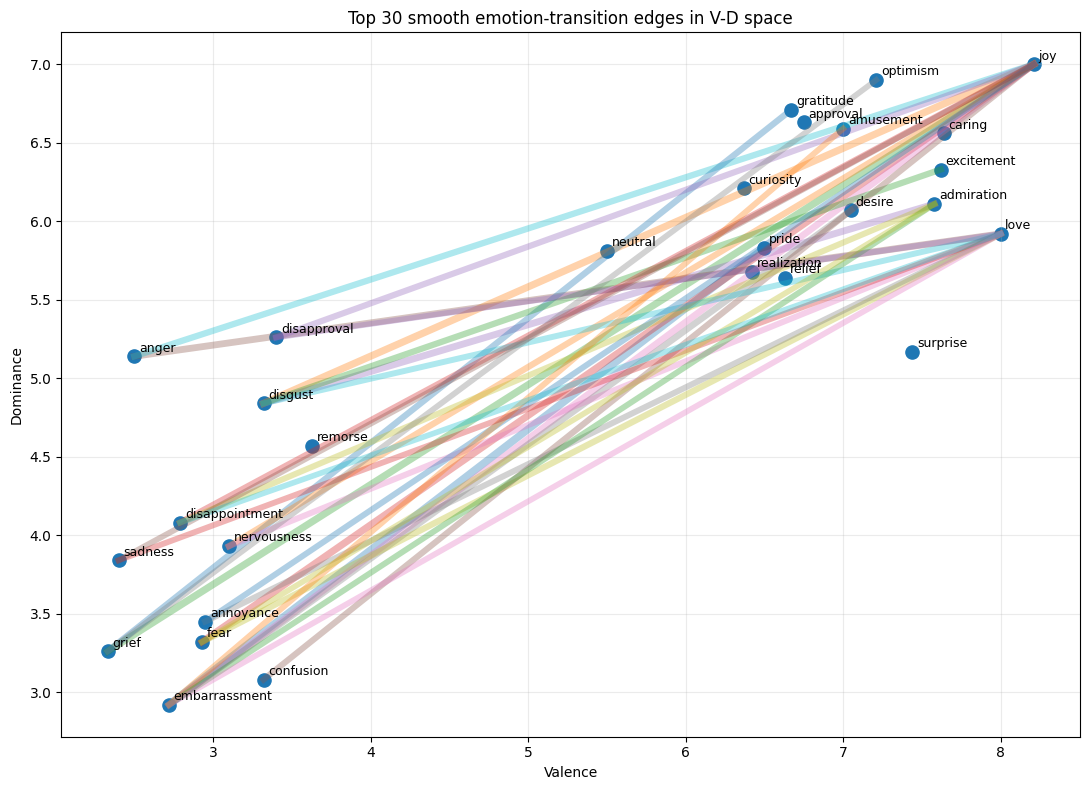

In [13]:
def plot_transition_network(
    results: pd.DataFrame,
    label_vd: pd.DataFrame,
    top_n: int = 30,
    min_score: float = 0.0,
    figsize: tuple[int, int] = (11, 8),
):
    if results.empty:
        raise ValueError("No transition results to plot.")
    coords = label_vd.set_index("label_name")[AFFECT_AXES]
    edges = results.dropna(subset=["smooth_score"]).query("smooth_score >= @min_score").copy()
    # Directed scans often contain both A->B and B->A. For a network view, keep one edge per unordered pair.
    edges["pair_key"] = edges.apply(lambda r: "--".join(sorted([str(r["source"]), str(r["target"])])), axis=1)
    edges = edges.sort_values("smooth_score", ascending=False).drop_duplicates("pair_key").head(top_n)

    fig, ax = plt.subplots(figsize=figsize)

    if len(edges):
        max_score = max(edges["smooth_score"].max(), 1e-12)
        for _, row in edges.iterrows():
            s, t = row["source"], row["target"]
            if s not in coords.index or t not in coords.index:
                continue
            xs = [coords.loc[s, "valence"], coords.loc[t, "valence"]]
            ys = [coords.loc[s, "dominance"], coords.loc[t, "dominance"]]
            lw = 0.5 + 5.0 * float(row["smooth_score"]) / max_score
            ax.plot(xs, ys, linewidth=lw, alpha=0.35)

    ax.scatter(coords["valence"], coords["dominance"], s=90)
    for label, row in coords.iterrows():
        ax.text(row["valence"] + 0.03, row["dominance"] + 0.03, label, fontsize=9)

    ax.set_xlabel("Valence")
    ax.set_ylabel("Dominance")
    ax.set_title(f"Top {len(edges)} smooth emotion-transition edges in V-D space")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    out = OUTPUT_DIR / "transition_network_valence_dominance.png"
    fig.savefig(out, dpi=220)
    print("Saved:", out)
    return fig, ax

plot_transition_network(transition_results, label_vd, top_n=30)
plt.show()

## 9. Inspect a specific transition

Change `FOCUS_SOURCE` and `FOCUS_TARGET`. Good starting pairs are `joy -> sadness`, `approval -> disapproval`, `fear -> relief`, `anger -> gratitude`, and whichever pair the scan says is interesting.


In [14]:
FOCUS_SOURCE = "joy"
FOCUS_TARGET = "sadness"

focus_transition, focus_path, focus_summary = analyze_transition(
    FOCUS_SOURCE,
    FOCUS_TARGET,
    max_points=1400,
    t_margin=0.10,
)

print(json.dumps(focus_summary, indent=2))
display(focus_path)

top_labels = exploded_label_counts(focus_transition["points"]).head(12)
display(top_labels.rename("n_in_transition_corridor_label_memberships").to_frame())


{
  "source": "joy",
  "target": "sadness",
  "n_points": 1400,
  "n_labels": 28,
  "n_multi_label_points": 0,
  "multi_label_fraction": 0.0,
  "n_bins": 12,
  "vd_distance": 6.613750826875775,
  "centroid_cosine_distance": 0.28057676553726196,
  "rho_t_embedding_projection": 0.5494991521197284,
  "pearson_t_embedding_projection": 0.5373319500895701,
  "rho_t_embedding_perp": 0.1262480899507693,
  "path_length": 5.375585556030273,
  "direct_path_distance": 0.856548011302948,
  "straightness": 0.15934041089571754,
  "mean_step_coherence": 0.1515473872423172,
  "path_jitter": 0.40574491024017334,
  "lexical_vad_fraction": 0.9842857142857143,
  "smooth_score": 0.05041325951209296
}


,bin,tone_bin_low,tone_bin_high,tone_t_center,n,n_multi_label,multi_label_fraction,mean_tone_t,mean_tone_perp,mean_embedding_t,mean_embedding_perp,dominant_label
0,0,0.000000,0.083333,0.041667,14,0,0.0,0.042403,0.044315,0.336143,1.052729,joy
1,1,0.083333,0.166667,0.125000,45,0,0.0,0.125675,0.052767,0.296063,1.069654,gratitude
2,2,0.166667,0.250000,0.208333,85,0,0.0,0.218437,0.059926,0.363444,1.077533,joy
3,3,0.250000,0.333333,0.291667,209,0,0.0,0.292965,0.052104,0.430112,1.100947,gratitude
4,4,0.333333,0.416667,0.375000,341,0,0.0,0.375140,0.054880,0.483052,1.121579,optimism
5,5,0.416667,0.500000,0.458333,302,0,0.0,0.458744,0.054323,0.547194,1.122776,optimism
6,6,0.500000,0.583333,0.541667,204,0,0.0,0.536090,0.054773,0.587940,1.115762,sadness
7,7,0.583333,0.666667,0.625000,96,0,0.0,0.620528,0.057140,0.617750,1.107530,fear
8,8,0.666667,0.750000,0.708333,46,0,0.0,0.703468,0.056520,0.605308,1.106061,sadness
9,9,0.750000,0.833333,0.791667,17,0,0.0,0.782744,0.053467,0.607537,1.082997,disgust


,n_in_transition_corridor_label_memberships
label_names_list,
joy,77
sadness,76
optimism,68
gratitude,68
caring,64
admiration,64
remorse,61
approval,61
desire,59


Saved: emotion_transition_outputs\transition_pca_joy_to_sadness.png


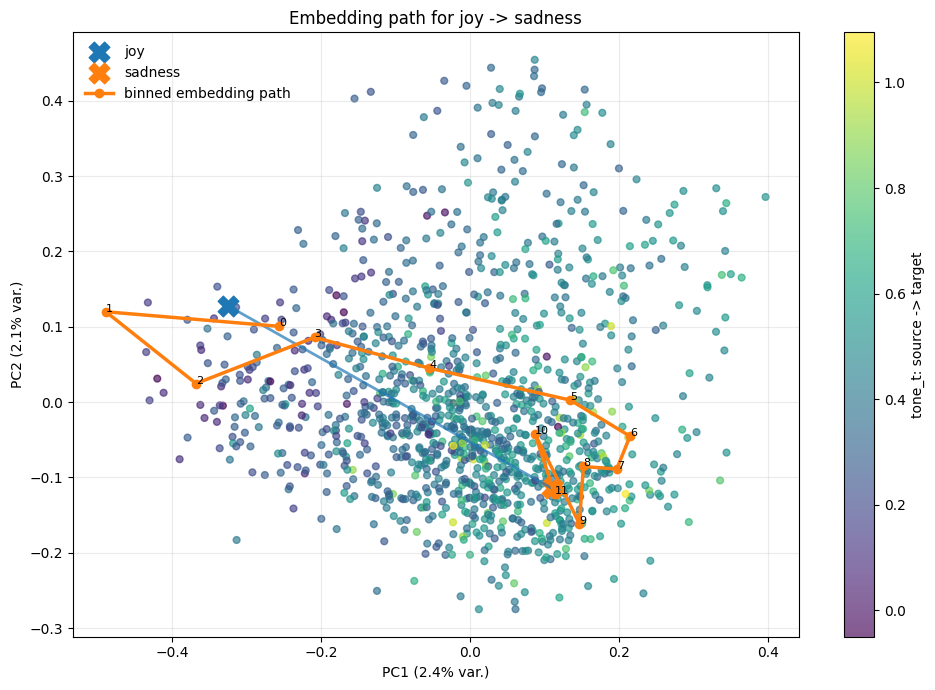

In [15]:
def plot_transition_pca(transition: dict, path: pd.DataFrame | None = None, sample_points: int = 1200):
    points = transition["points"].copy()
    X_points = transition["X_points"]
    if len(points) > sample_points:
        sampled = points.sample(n=sample_points, random_state=SEED).sort_index()
        X_plot = X_points[sampled.index.to_numpy()]
        points_plot = sampled.reset_index(drop=True)
    else:
        X_plot = X_points
        points_plot = points.reset_index(drop=True)

    extra = np.vstack([transition["source_centroid"], transition["target_centroid"]])
    fit_X = np.vstack([X_plot, extra])
    pca = PCA(n_components=2, random_state=SEED)
    Z = pca.fit_transform(fit_X)
    Z_points = Z[:len(X_plot)]
    Z_src, Z_tgt = Z[-2], Z[-1]

    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(Z_points[:, 0], Z_points[:, 1], c=points_plot["tone_t"], s=24, alpha=0.65)
    fig.colorbar(sc, ax=ax, label="tone_t: source -> target")

    ax.scatter([Z_src[0]], [Z_src[1]], marker="X", s=220, label=transition["source"])
    ax.scatter([Z_tgt[0]], [Z_tgt[1]], marker="X", s=220, label=transition["target"])
    ax.plot([Z_src[0], Z_tgt[0]], [Z_src[1], Z_tgt[1]], linewidth=2, alpha=0.7)

    if path is not None and len(path):
        C = path.attrs["centroids"]
        C2 = pca.transform(C)
        ax.plot(C2[:, 0], C2[:, 1], marker="o", linewidth=2.5, label="binned embedding path")
        for i, row in path.reset_index(drop=True).iterrows():
            ax.text(C2[i, 0], C2[i, 1], str(int(row["bin"])), fontsize=8)

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)")
    ax.set_title(f"Embedding path for {transition['source']} -> {transition['target']}")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    out = OUTPUT_DIR / f"transition_pca_{transition['source']}_to_{transition['target']}.png"
    fig.savefig(out, dpi=220)
    print("Saved:", out)
    return fig, ax

plot_transition_pca(focus_transition, focus_path)
plt.show()


### 9b. Interactive 3D PCA path of tone-bin embedding means

This plot uses the mean embedding/centroid for each valid tone bin. It is not the raw comment cloud; it is the binned path through embedding space, shown in the first three principal components so the path geometry is less flattened than in the 2D view.


In [16]:
def plot_binned_path_pca3d(transition: dict, path: pd.DataFrame):
    if path.empty:
        raise ValueError("No valid bins to plot in 3D.")
    C = path.attrs.get("centroids")
    if C is None or len(C) < 2:
        raise ValueError("Path centroids are missing or too few for a 3D PCA plot.")

    # Fit PCA to source endpoint, target endpoint, and the bin mean embeddings.
    fit_X = np.vstack([transition["source_centroid"], C, transition["target_centroid"]])
    n_components = min(3, fit_X.shape[0], fit_X.shape[1])
    if n_components < 3:
        raise ValueError("Need at least three points/components for a 3D PCA plot.")
    pca = PCA(n_components=3, random_state=SEED)
    Z = pca.fit_transform(fit_X)
    Z_source = Z[0]
    Z_bins = Z[1:-1]
    Z_target = Z[-1]

    try:
        import plotly.graph_objects as go
    except ImportError as exc:
        raise ImportError("Install plotly to use the interactive 3D transition plot: pip install plotly") from exc

    hover = [
        f"bin={int(row.bin)}<br>tone=[{row.tone_bin_low:.2f}, {row.tone_bin_high:.2f}]"
        f"<br>mean tone_t={row.mean_tone_t:.3f}<br>n={int(row.n)}"
        f"<br>multi-label fraction={row.multi_label_fraction:.2f}"
        f"<br>dominant label={row.dominant_label}"
        for _, row in path.iterrows()
    ]

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=Z_bins[:, 0], y=Z_bins[:, 1], z=Z_bins[:, 2],
        mode="lines+markers+text",
        text=[str(int(b)) for b in path["bin"]],
        textposition="top center",
        marker=dict(size=7, color=path["mean_tone_t"], colorscale="Viridis", colorbar=dict(title="mean tone_t")),
        line=dict(width=5),
        hovertext=hover,
        hoverinfo="text",
        name="tone-bin mean embeddings",
    ))
    fig.add_trace(go.Scatter3d(
        x=[Z_source[0], Z_target[0]], y=[Z_source[1], Z_target[1]], z=[Z_source[2], Z_target[2]],
        mode="markers+text",
        text=[transition["source"], transition["target"]],
        textposition="bottom center",
        marker=dict(size=10, symbol="diamond"),
        name="source/target centroids",
    ))
    fig.add_trace(go.Scatter3d(
        x=[Z_source[0], Z_target[0]], y=[Z_source[1], Z_target[1]], z=[Z_source[2], Z_target[2]],
        mode="lines",
        line=dict(width=3),
        name="direct source-target line",
    ))

    fig.update_layout(
        title=f"3D PCA of binned embedding means: {transition['source']} -> {transition['target']}",
        scene=dict(
            xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var.)",
            yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var.)",
            zaxis_title=f"PC3 ({pca.explained_variance_ratio_[2] * 100:.1f}% var.)",
        ),
        margin=dict(l=0, r=0, b=0, t=45),
    )
    out = OUTPUT_DIR / f"transition_bin_means_3d_pca_{transition['source']}_to_{transition['target']}.html"
    fig.write_html(out)
    print("Saved:", out)
    fig.show()
    return fig

plot_binned_path_pca3d(focus_transition, focus_path)


Saved: emotion_transition_outputs\transition_bin_means_3d_pca_joy_to_sadness.html


Saved: emotion_transition_outputs\transition_projection_profile_joy_to_sadness.png


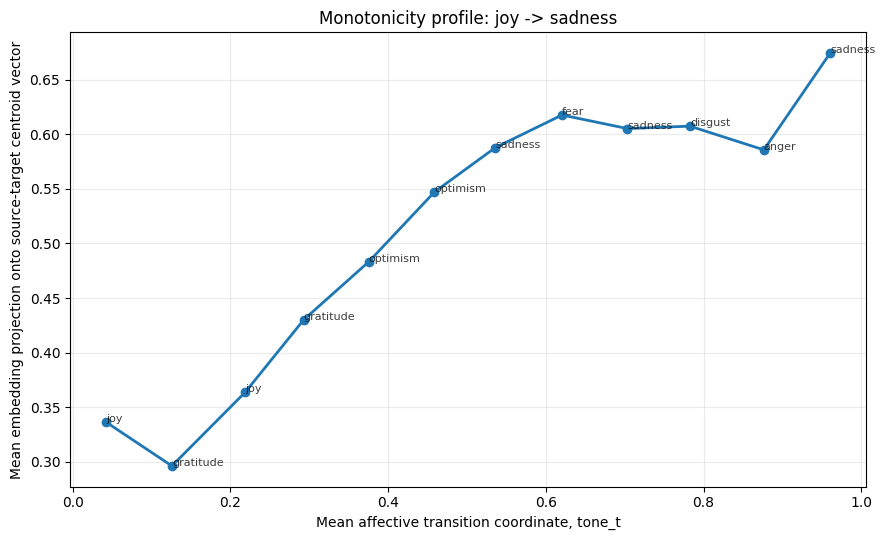

Saved: emotion_transition_outputs\transition_step_lengths_joy_to_sadness.png


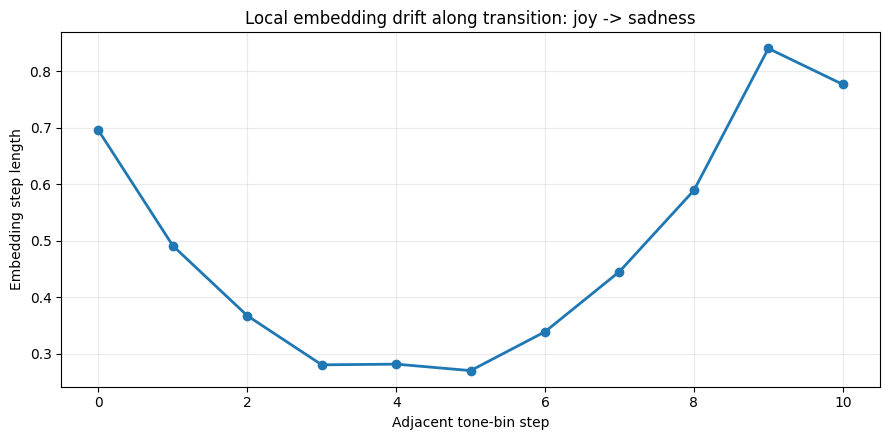

In [17]:
def plot_transition_profiles(path: pd.DataFrame, source: str, target: str):
    if path.empty:
        raise ValueError("No valid bins to plot.")

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(path["mean_tone_t"], path["mean_embedding_t"], marker="o", linewidth=2)
    for _, row in path.iterrows():
        ax.text(row["mean_tone_t"], row["mean_embedding_t"], str(row["dominant_label"]), fontsize=8, alpha=0.75)
    ax.set_xlabel("Mean affective transition coordinate, tone_t")
    ax.set_ylabel("Mean embedding projection onto source-target centroid vector")
    ax.set_title(f"Monotonicity profile: {source} -> {target}")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    out = OUTPUT_DIR / f"transition_projection_profile_{source}_to_{target}.png"
    fig.savefig(out, dpi=220)
    print("Saved:", out)
    plt.show()

    C = path.attrs.get("centroids")
    if C is not None and len(C) >= 2:
        step_lengths = np.linalg.norm(np.diff(C, axis=0), axis=1)
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.plot(np.arange(len(step_lengths)), step_lengths, marker="o", linewidth=2)
        ax.set_xlabel("Adjacent tone-bin step")
        ax.set_ylabel("Embedding step length")
        ax.set_title(f"Local embedding drift along transition: {source} -> {target}")
        ax.grid(True, alpha=0.25)
        fig.tight_layout()
        out = OUTPUT_DIR / f"transition_step_lengths_{source}_to_{target}.png"
        fig.savefig(out, dpi=220)
        print("Saved:", out)
        plt.show()

plot_transition_profiles(focus_path, FOCUS_SOURCE, FOCUS_TARGET)


## 10. Show example comments across every tone level

The previous version showed only a few broad intervals. This version samples representative comments from every valid `tone_t` bin in the focused transition path. Multi-label comments show their full `label_names` field, because apparently one label was too emotionally monogamous.


In [18]:
def sample_comments_across_transition(
    transition: dict,
    path: pd.DataFrame | None = None,
    bins: Sequence[tuple[float, float]] | None = None,
    n_per_bin: int = 4,
) -> pd.DataFrame:
    """Show representative comments for every tone_t level/bin.

    Rows are chosen close to the VD corridor and close to each bin's mean tone_t,
    so examples should represent the level rather than just be random chaos with punctuation.
    """
    points = transition["points"].copy()
    bin_specs = []

    if bins is not None:
        for j, (lo, hi) in enumerate(bins):
            bin_specs.append((j, float(lo), float(hi), (float(lo) + float(hi)) / 2))
    elif path is not None and len(path):
        for _, row in path.iterrows():
            bin_specs.append((int(row["bin"]), float(row["tone_bin_low"]), float(row["tone_bin_high"]), float(row["mean_tone_t"])))
    else:
        edges = np.linspace(0.0, 1.0, 13)
        for j in range(len(edges) - 1):
            bin_specs.append((j, float(edges[j]), float(edges[j + 1]), float((edges[j] + edges[j + 1]) / 2)))

    rows = []
    last_bin_id = bin_specs[-1][0] if bin_specs else None
    for bin_id, lo, hi, center in bin_specs:
        if bin_id == last_bin_id:
            chunk = points[points["tone_t"].between(lo, hi, inclusive="both")].copy()
        else:
            chunk = points[(points["tone_t"] >= lo) & (points["tone_t"] < hi)].copy()
        if chunk.empty:
            continue
        chunk["representative_score"] = chunk["tone_perp"] + 0.5 * (chunk["tone_t"] - center).abs()
        chunk = chunk.sort_values("representative_score", ascending=True).head(max(n_per_bin * 5, n_per_bin))
        chunk = chunk.sample(n=min(n_per_bin, len(chunk)), random_state=SEED).sort_values("tone_t")
        chunk["tone_bin_id"] = int(bin_id)
        chunk["tone_bin"] = f"bin {bin_id}: {lo:.2f}-{hi:.2f}"
        rows.append(chunk[[
            "tone_bin_id", "tone_bin", "tone_t", "tone_perp", "embedding_t", "label_name", "label_names", "n_labels",
            "text", "lex_vd_n_words", "comment_vd_source", "representative_score",
        ]])
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True).sort_values(["tone_bin_id", "tone_t"])

examples = sample_comments_across_transition(focus_transition, path=focus_path, n_per_bin=4)
display(examples)
examples_path = OUTPUT_DIR / f"example_comments_{FOCUS_SOURCE}_to_{FOCUS_TARGET}.csv"
examples.to_csv(examples_path, index=False)
print("Saved:", examples_path)


,tone_bin_id,tone_bin,tone_t,tone_perp,embedding_t,label_name,label_names,n_labels,text,lex_vd_n_words,comment_vd_source,representative_score
0,0,bin 0: 0.00-0.08,0.066309,5.292005e-04,0.180500,excitement,excitement,1,And a happy holiday to you.,2,lexical_average,0.012482
1,0,bin 0: 0.00-0.08,0.077366,8.477791e-02,0.335177,admiration,admiration,1,This is so amazing 😍,1,lexical_average,0.102259
2,0,bin 0: 0.00-0.08,0.077366,8.477791e-02,0.335116,admiration,admiration,1,You are amazing,1,lexical_average,0.102259
3,0,bin 0: 0.00-0.08,0.082038,9.762237e-02,0.242675,love,love,1,Yes! I love her laugh so much,2,lexical_average,0.117440
4,1,bin 1: 0.08-0.17,0.083984,1.663201e-02,0.267666,gratitude,gratitude,1,thanks <3,1,lexical_average,0.037477
5,1,bin 1: 0.08-0.17,0.089414,1.986770e-02,0.583380,embarrassment,embarrassment,1,Still pretty embarrasing though :p,1,lexical_average,0.037998
6,1,bin 1: 0.08-0.17,0.106347,2.346122e-02,0.265539,joy,joy,1,Luckiest I’ve been is getting the toy I actual...,3,lexical_average,0.033125
7,1,bin 1: 0.08-0.17,0.153007,1.877906e-02,0.195789,gratitude,gratitude,1,Thank you for your support!,2,lexical_average,0.032445
8,2,bin 2: 0.17-0.25,0.211535,6.317142e-03,0.455451,admiration,admiration,1,Lullaby is excellent and so is Diary. His firs...,5,lexical_average,0.009768
9,2,bin 2: 0.17-0.25,0.213408,1.066717e-02,0.361950,caring,caring,1,Peace be with you,2,lexical_average,0.013181


Saved: emotion_transition_outputs\example_comments_joy_to_sadness.csv


## 11. Heatmaps for transition metrics


Saved: emotion_transition_outputs\heatmap_smooth_score.png


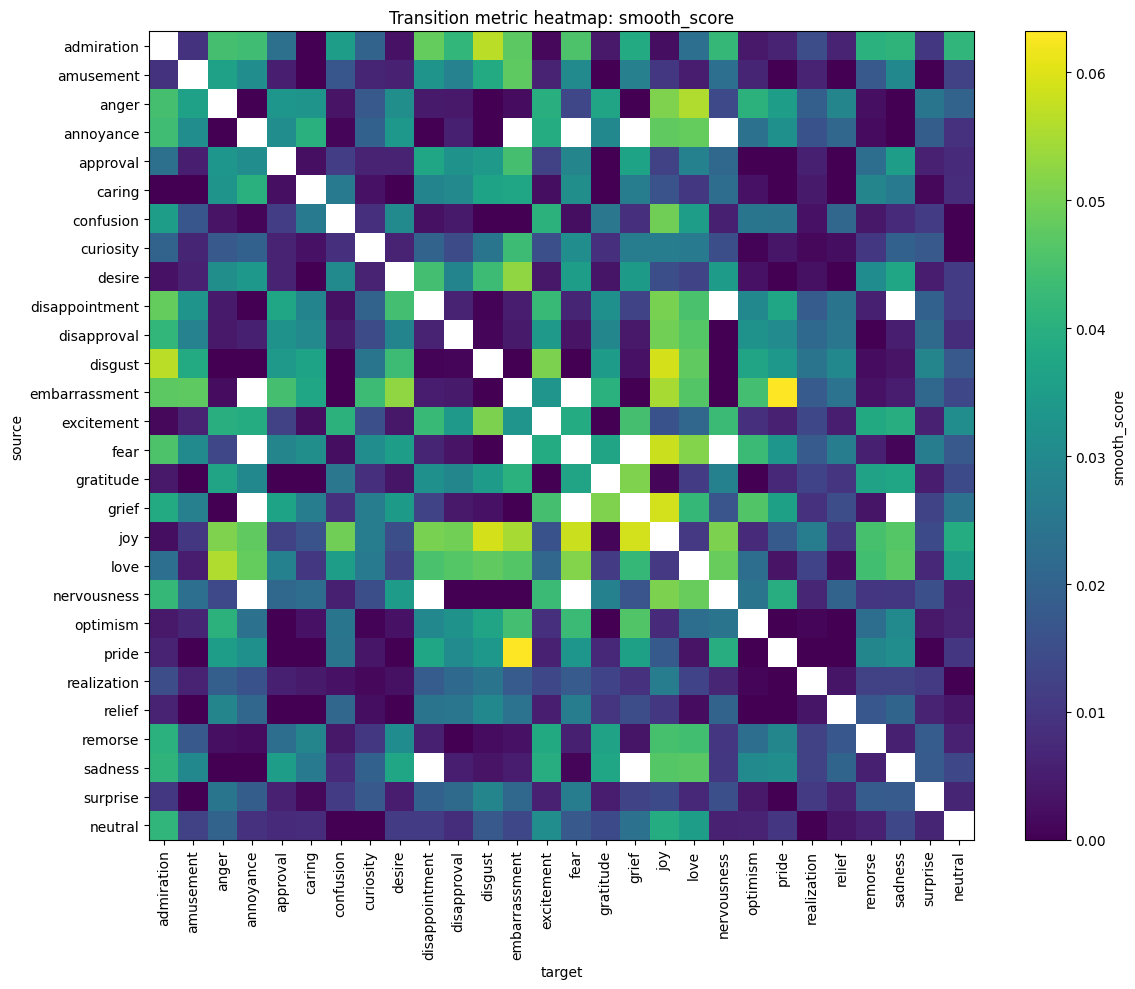

Saved: emotion_transition_outputs\heatmap_straightness.png


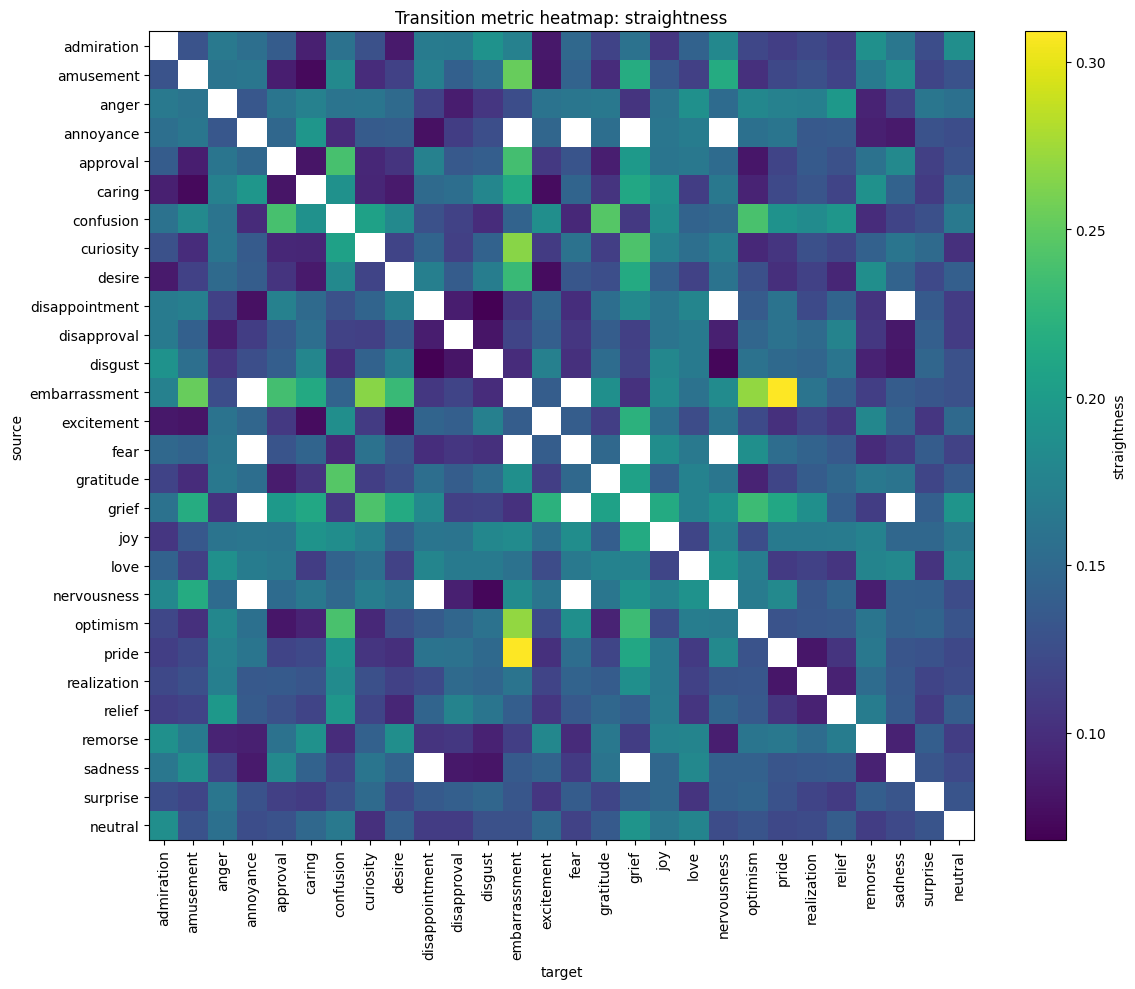

In [19]:
def metric_matrix(results: pd.DataFrame, metric: str, labels: Sequence[str]) -> pd.DataFrame:
    mat = pd.DataFrame(np.nan, index=labels, columns=labels, dtype=float)
    for _, row in results.dropna(subset=[metric]).iterrows():
        if row["source"] in mat.index and row["target"] in mat.columns:
            mat.loc[row["source"], row["target"]] = float(row[metric])
    return mat


def plot_metric_heatmap(results: pd.DataFrame, metric: str, labels: Sequence[str] | None = None):
    if labels is None:
        labels = sorted(set(results["source"]).union(set(results["target"])))
    mat = metric_matrix(results, metric, labels)

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(mat.to_numpy(), aspect="auto")
    fig.colorbar(im, ax=ax, label=metric)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    ax.set_xlabel("target")
    ax.set_ylabel("source")
    ax.set_title(f"Transition metric heatmap: {metric}")
    fig.tight_layout()
    out = OUTPUT_DIR / f"heatmap_{metric}.png"
    fig.savefig(out, dpi=220)
    print("Saved:", out)
    return fig, ax

plot_metric_heatmap(transition_results, "smooth_score", labels_present)
plt.show()
plot_metric_heatmap(transition_results, "straightness", labels_present)
plt.show()


## 12. Interpretation guide

Use the table and plots like this:

- **High `rho_t_embedding_projection`, high `straightness`, high `mean_step_coherence`:** embedding movement is nearly a straight semantic drift from source to target.
- **High `rho_t_embedding_projection`, low `straightness`:** tone changes monotonically, but the embedding path bends. That can mean intermediate semantic regimes exist between the emotions.
- **Low or negative `rho_t_embedding_projection`:** lexical affect changes do not align with the source-target embedding axis. Either the pair is not a meaningful gradual transition, the VD approximation is weak, or the embedding is capturing pragmatic/contextual information rather than affect alone. Human language, tragically, contains context.
- **High `path_jitter`:** the transition has uneven embedding jumps, often because bins are dominated by different labels or noisy comments.
- **Low `lexical_vad_fraction`:** many comments fell back to label-level VD; treat that transition as label-driven rather than text-driven.

Suggested robustness checks:

1. Compare lexical comment VD with label-only VD by setting `prefer_lexical_vad=False` inside `select_transition_corridor`.
2. Increase `MAX_TOTAL` in the embedding builder to reduce sparse-bin artifacts.
3. Re-run with multiple embedding models.
4. Repeat the scan with `max_points`, `t_margin`, `n_bins`, and `min_bin_count` varied.
5. Inspect sampled comments, because numbers without examples are how spreadsheets develop delusions of grandeur.


## 13. Export compact report tables


In [20]:
report_cols = [
    "source", "target", "smooth_score", "rho_t_embedding_projection", "straightness",
    "mean_step_coherence", "path_jitter", "n_points", "n_labels", "n_multi_label_points",
    "multi_label_fraction", "n_bins", "vd_distance", "centroid_cosine_distance", "lexical_vad_fraction",
]

compact = transition_results[[c for c in report_cols if c in transition_results.columns]].copy()
compact_path = OUTPUT_DIR / "emotion_transition_compact_report.csv"
compact.to_csv(compact_path, index=False)
print("Saved:", compact_path)
display(compact.head(30))


Saved: emotion_transition_outputs\emotion_transition_compact_report.csv


,source,target,smooth_score,rho_t_embedding_projection,straightness,mean_step_coherence,path_jitter,n_points,n_labels,n_multi_label_points,multi_label_fraction,n_bins,vd_distance,centroid_cosine_distance,lexical_vad_fraction
0,pride,embarrassment,0.063218,0.373200,0.309005,0.096387,0.356572,1000,28,0,0.0,7,4.770377,0.317987,0.996
1,embarrassment,pride,0.063218,0.373200,0.309005,0.096387,0.356572,1000,28,0,0.0,7,4.770377,0.317987,0.996
2,disgust,joy,0.059138,0.587736,0.179110,0.123548,0.363347,1000,28,0,0.0,12,5.345811,0.380310,0.952
3,joy,disgust,0.059138,0.587736,0.179110,0.123548,0.363347,1000,28,0,0.0,12,5.345811,0.380310,0.952
4,grief,joy,0.058856,0.498812,0.215338,0.095886,0.356487,1000,28,0,0.0,10,6.968644,0.419475,0.991
5,joy,grief,0.058856,0.498812,0.215338,0.095886,0.356487,1000,28,0,0.0,10,6.968644,0.419475,0.991
6,fear,joy,0.058128,0.549232,0.186554,0.134625,0.339865,1000,28,0,0.0,11,6.435899,0.378018,0.984
7,joy,fear,0.058128,0.549232,0.186554,0.134625,0.339865,1000,28,0,0.0,11,6.435899,0.378018,0.984
8,disgust,admiration,0.056645,0.522944,0.191269,0.132633,0.391453,1000,28,0,0.0,12,4.445278,0.319366,0.988
9,admiration,disgust,0.056645,0.522944,0.191269,0.132633,0.391453,1000,28,0,0.0,12,4.445278,0.319366,0.988


## 14. Optional: compare transition scores with centroid-level manifold alignment

If you also ran `goemotions_manifold_analysis.py`, you can compare these transition-level results to the global centroid-level alignment results. The two analyses answer different questions:

- centroid-level manifold alignment asks whether distances among emotion labels resemble VD distances overall;
- this notebook asks whether **ordered local paths** between two emotion endpoints are smooth in embedding space.


In [21]:
MANIFOLD_RESULTS_PATH = first_existing(
    *candidates("manifold_outputs", "analysis", "distance_alignment_results.csv"),
    *candidates("distance_alignment_results.csv"),
)

if MANIFOLD_RESULTS_PATH is not None:
    manifold_results = pd.read_csv(MANIFOLD_RESULTS_PATH)
    display(manifold_results.sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False).head(20))
else:
    print("No manifold distance_alignment_results.csv found. This comparison is optional, not a moral failing. Probably.")


,level,n_points,representation,pca_dim_requested,explained_variance,distance_method,knn_k,graph_connected_components,ground_truth_space,permutation_p_abs_spearman,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p,n_pairs
53,comment_centroid,28,pca_10,10,0.766721,knn_geodesic_angular,3.0,1.0,valence,0.009901,0.695096,7.621937e-56,0.679765,1.429365e-52,0.464721,2.095630e-41,378
66,comment_centroid,28,pca_25,25,0.992096,knn_geodesic_angular,2.0,1.0,VAD,0.009901,0.694175,1.214858e-55,0.674093,2.071191e-51,0.475011,2.982520e-43,378
20,comment_centroid,28,pca_2,2,0.303420,direct_angular,NaN,NaN,valence,0.009901,0.680243,1.138244e-52,0.666855,5.759145e-50,0.463232,3.759068e-41,378
17,comment_centroid,28,pca_2,2,0.303420,direct_cosine,NaN,NaN,valence,0.009901,0.687462,3.445160e-54,0.666855,5.759145e-50,0.463232,3.759068e-41,378
23,comment_centroid,28,pca_2,2,0.303420,knn_geodesic_angular,3.0,1.0,valence,0.009901,0.680243,1.138104e-52,0.666855,5.759145e-50,0.463232,3.759068e-41,378
29,comment_centroid,28,pca_2,2,0.303420,knn_geodesic_angular,10.0,1.0,valence,0.009901,0.680243,1.138089e-52,0.666855,5.759145e-50,0.463232,3.759068e-41,378
26,comment_centroid,28,pca_2,2,0.303420,knn_geodesic_angular,5.0,1.0,valence,0.009901,0.680243,1.138089e-52,0.666855,5.759145e-50,0.463232,3.759068e-41,378
68,comment_centroid,28,pca_25,25,0.992096,knn_geodesic_angular,2.0,1.0,valence,0.009901,0.691429,4.826175e-55,0.666773,5.977933e-50,0.459748,1.464362e-40,378
24,comment_centroid,28,pca_2,2,0.303420,knn_geodesic_angular,5.0,1.0,VAD,0.009901,0.677115,5.022964e-52,0.665883,8.939789e-50,0.471109,1.424215e-42,378
21,comment_centroid,28,pca_2,2,0.303420,knn_geodesic_angular,3.0,1.0,VAD,0.009901,0.677115,5.023012e-52,0.665883,8.939789e-50,0.471109,1.424215e-42,378
